# Multi-objective optimization

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from smt.sampling_methods import LHS
from smt_optim.core import Driver, ObjectiveConfig, ConstraintConfig, DriverConfig, Problem

from smt_optim.surrogate_models.smt import SmtGPX

from smt_optim.acquisition_strategies.multiobj import MOSEGO
from smt_optim.acquisition_functions.multi_obj import init_mpi
from smt_optim.utils.multi_obj import get_pareto_front, get_pf_from_dataset

from smt_optim.benchmarks.registry import get_problem
from smt_optim.utils.plot_2d import get_plot2d_data

from smt_optim.benchmarks.base import PymooWrapper
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize


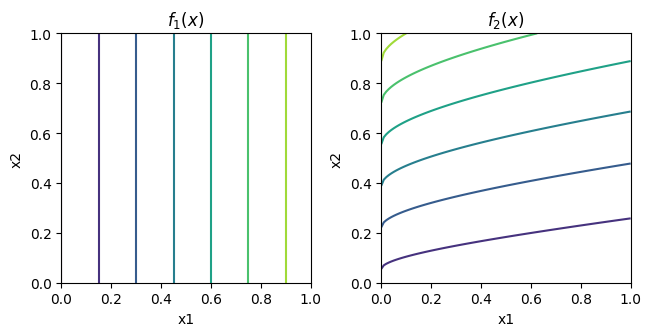

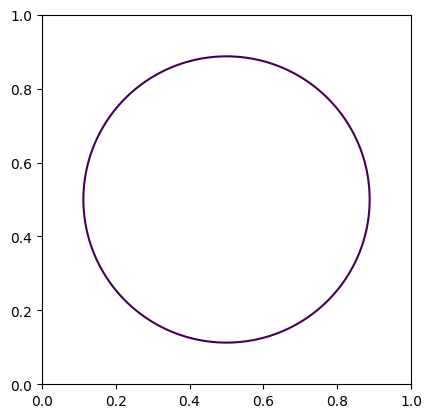

In [11]:

problem = get_problem("ZDT1")

problem.set_dim(2)

x1 = np.linspace(0, 1, 101)
x2 = np.linspace(0, 1, 101)

XX, YY = np.meshgrid(x1, x2)

data = np.vstack((XX.ravel(), YY.ravel())).T
f1 = np.empty(data.shape[0])
f2 = np.empty(data.shape[0])

for i in range(data.shape[0]):
    f1[i] = problem.f1(data[i, :])
    f2[i] = problem.f2(data[i, :])

F1 = f1.reshape(XX.shape)
F2 = f2.reshape(XX.shape)

fig, ax = plt.subplots(1, 2, layout="constrained")
ax[0].set_title(r"$f_1(x)$")
ax[0].contour(XX, YY, F1)
ax[1].set_title(r"$f_2(x)$")
ax[1].contour(XX, YY, F2)

for idx in range(2):
    ax[idx].set_xlabel("x1")
    ax[idx].set_ylabel("x2")
    ax[idx].set_aspect("equal")

plt.show()


In [3]:
obj_config = ObjectiveConfig(
    [problem.f1],
    type="minimize",
    surrogate=SmtGPX,
)

obj_config2 = ObjectiveConfig(
    [problem.f2],
    type="minimize",
    surrogate=SmtGPX,
)

# cstr_config = ConstraintConfig(
#     [g],
#     upper=0.,
#     surrogate=SmtAutoModel,
# )

prob_definition = Problem(
    obj_configs=[obj_config, obj_config2],
    # cstr_configs=[cstr_config],
    design_space=problem.bounds,            # problem bounds
)

nt_init = 6

opt_config = DriverConfig(
    max_iter = 50,
    nt_init = nt_init,
    verbose = True,
    scaling = True,
    seed=0,
)

# np.seterr(all="raise")

# driver = Driver(prob_definition, opt_config, MultiObj, strategy_kwargs={"acq_func": init_mpi, "n_start": 1000, "sp_method": None})
driver = Driver(prob_definition, opt_config, MOSEGO, strategy_kwargs={"acq_func": init_mpi, "n_start": 50, "sp_method": "Cobyla"})


In [ ]:
state = driver.optimize()

          iter         budget             HV        spacing       fidelity        gp_time       acq_time
             0              6    4.95980e+00    2.22728e+00            nan            nan            nan


In [ ]:

# ======= Optimization Pareto Front =======
data = driver.state.dataset.export_as_dict()
obj = data["obj"]
obj_par = get_pareto_front(obj)

# ======= Solution Pareto Front =======
x1 = np.linspace(0, 1, 101)
x2 = np.linspace(0, 0, 101)

XX, YY = np.meshgrid(x1, x2)

data = np.vstack((XX.ravel(), YY.ravel())).T
f1 = np.empty(data.shape[0])
f2 = np.empty(data.shape[0])

for i in range(data.shape[0]):
    f1[i] = problem.f1(data[i, :])
    f2[i] = problem.f2(data[i, :])

F1 = f1.reshape(XX.shape)
F2 = f2.reshape(XX.shape)

ref_pareto = get_pareto_front(np.vstack((f1, f2)).T)

# ======= Plot optimization and solution pareto front =======
fig, ax = plt.subplots()

ax.scatter(obj[:, 0], obj[:, 1])
ax.scatter(obj[:nt_init, 0], obj[:nt_init, 1], color="C2")
ax.scatter(obj_par[:, 0], obj_par[:, 1], marker="d", color="C3")

sorted_idx = np.argsort(obj_par[:, 0])
obj_par = obj_par[sorted_idx, :]

# PF obtained through optimization
ax.step(obj_par[:, 0], obj_par[:, 1], where="post", color="C3", zorder=20)

# Solution PF
# ax.scatter(F1, F2, 2, color="C7", alpha=0.2, zorder=10)
ax.scatter(ref_pareto[:, 0], ref_pareto[:, 1], 2, color="C7", alpha=0.2, zorder=10)

ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")

ax.set_xlim((-0.1, 1.1))
ax.set_ylim((-0.1, 1.1))

plt.show()


## Constrained multi-objective optimization

In [44]:
problem = get_problem("DTLZ5")
problem.set_dim(2)


In [48]:

obj_config = ObjectiveConfig(
    [problem.objective[0][-1]],
    type="minimize",
    surrogate=SmtGPX,
)

obj_config2 = ObjectiveConfig(
    [problem.objective[1][-1]],
    type="minimize",
    surrogate=SmtGPX,
)

cstr_config = ConstraintConfig(
    [problem.constraints[0][-1]],
    upper=0.,
    surrogate=SmtGPX,
)

prob_definition = Problem(
    obj_configs=[obj_config, obj_config2],
    cstr_configs=[cstr_config],
    design_space=problem.bounds,            # problem bounds
)

nt_init = 12

opt_config = DriverConfig(
    max_iter = 30,
    nt_init = nt_init,
    verbose = True,
    scaling = True,
    seed=0,
)

# np.seterr(all="raise")

# driver = Driver(prob_definition, opt_config, MultiObj, strategy_kwargs={"acq_func": init_mpi, "n_start": 1000, "sp_method": None})
driver = Driver(prob_definition, opt_config, MOSEGO, strategy_kwargs={"acq_func": init_mpi, "n_start": 40, "sp_method": "SLSQP"})


In [49]:
state = driver.optimize()

          iter         budget             HV        spacing       fidelity        gp_time       acq_time
             0             12    6.15500e-03    8.03454e-02            nan            nan            nan
             1             13    6.22752e-03    9.74799e-02              1          0.071          0.041
             2             14    6.22752e-03    9.15845e-02              1          0.085          0.049
             3             15    6.43611e-03    9.11532e-02              1          0.091          0.048
             4             16    6.43611e-03    4.97171e-02              1          0.109          0.049
             5             17    6.43611e-03    4.65390e-02              1          0.134          0.052
             6             18    6.43611e-03    1.81715e-02              1          0.118          0.063
             7             19    6.43611e-03    2.20643e-02              1          0.108          0.080
             8             20    6.56079e-03    1.77317

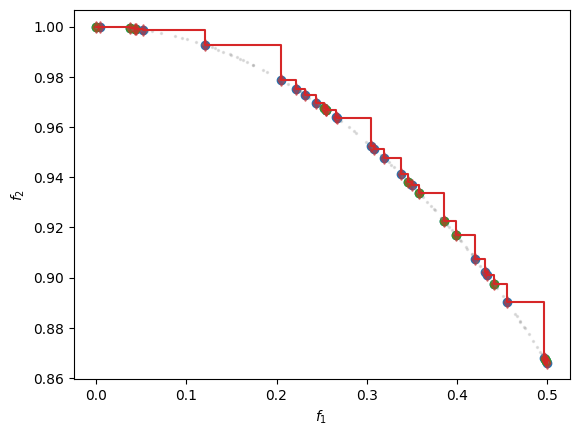

In [52]:

# ======= Optimization Pareto Front =======
# dataset = driver.dataset
data = driver.state.dataset.export_as_dict()
obj = data["obj"]
rscv = data["rscv"]
obj = obj[rscv <= 1e-4, :]
# obj_par = get_pareto_front(obj)

pareto_front = get_pf_from_dataset(state.dataset)

# ======= Solution Pareto Front =======
pymoo_prob = PymooWrapper(problem)

algorithm = NSGA2(pop_size=100, seed=1)
res = minimize(pymoo_prob, algorithm, ("n_gen", 30), seed=1)



# ======= Plot optimization and solution pareto front =======
fig, ax = plt.subplots()

ax.scatter(obj[:, 0], obj[:, 1])
ax.scatter(obj[:nt_init, 0], obj[:nt_init, 1], color="C2")

sorted_idx = np.argsort(pareto_front[:, 0])
pareto_front = pareto_front[sorted_idx, :]

# PF obtained through optimization
ax.step(pareto_front[:, 0], pareto_front[:, 1], where="post", color="C3", zorder=20)
ax.scatter(pareto_front[:, 0], pareto_front[:, 1], marker="d", color="C3", alpha=0.5)

# Solution PF
# ax.scatter(F1, F2, 2, color="C7", alpha=0.2, zorder=10)
ax.scatter(res.F[:, 0], res.F[:, 1], 2, color="C7", alpha=0.2, zorder=10)

ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")

# ax.set_xlim((-0.1, 1.1))
# ax.set_ylim((-0.1, 1.1))

plt.show()

## Constrained, multi-fidelity, and multi-objective optimization